### Import Train Dataset

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
train = pd.read_csv('train.csv')
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Univariate Analysis

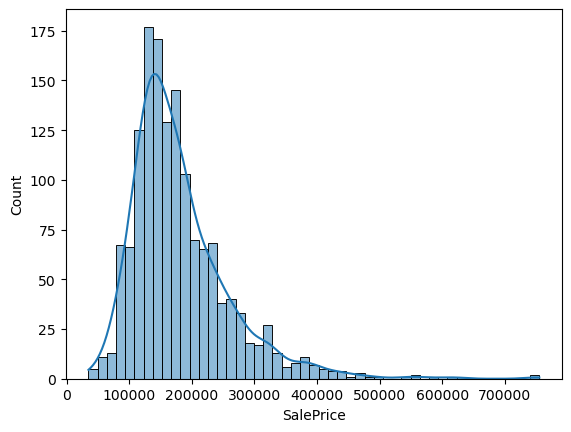

In [3]:
sns.histplot(train['SalePrice'], kde=True)
plt.show()

### Data Transformation

In [ ]:
from scipy import stats
import numpy as np

transformed_data, lambda_opt = stats.boxcox(train['SalePrice'])
print(f'Optimal lambda for Box-Cox transformation: {lambda_opt}')

Optimal lambda for Box-Cox transformation: -0.07692397686078907


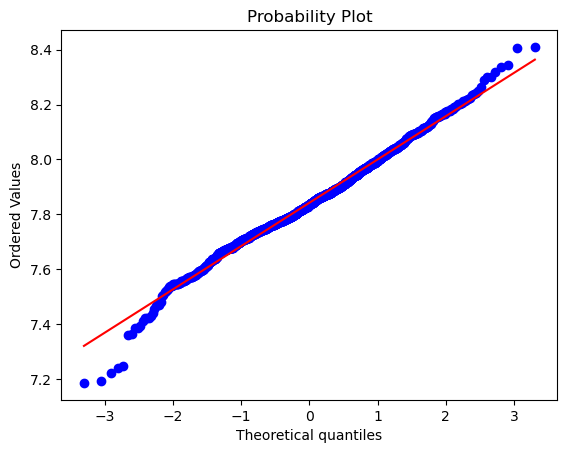

In [7]:
stats.probplot(transformed_data, dist="norm", plot=plt)
plt.show()

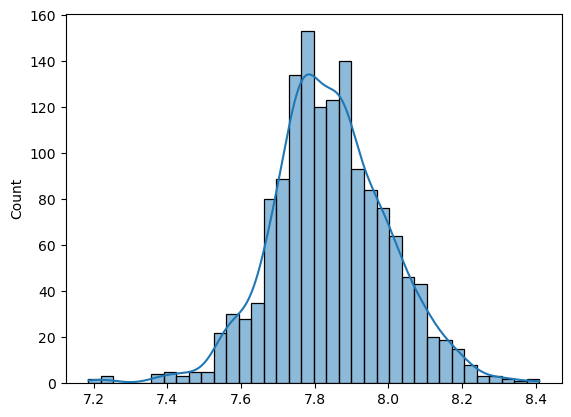

In [8]:
sns.histplot(transformed_data, kde=True)
plt.show()

In [ ]:
train['log_SalePrice'] = transformed_data
train['log_SalePrice'].describe()

count    1460.000000
mean        7.842249
std         0.158257
min         7.185700
25%         7.745004
50%         7.835731
75%         7.942747
max         8.410159
Name: log_SalePrice, dtype: float64

## Multivariate Analysis

In [10]:
multi_test = train.select_dtypes('number').corr()['log_SalePrice'].sort_values(ascending=False)
# print(multi_test)

# eliminate features
importances_feat = multi_test[multi_test > 0.5].index

print(importances_feat)


Index(['log_SalePrice', 'SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars',
       'GarageArea', 'TotalBsmtSF', 'FullBath', '1stFlrSF', 'YearBuilt',
       'YearRemodAdd', 'GarageYrBlt', 'TotRmsAbvGrd'],
      dtype='object')


### Building model

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Prepare the data for modeling
X = train[importances_feat].drop(['log_SalePrice', 'SalePrice'], axis=1)
y = train['log_SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle missing values
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# Build the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')




Mean Squared Error: 0.004757897191132128
R-squared: 0.8381255648581205


In [ ]:
# Adjusted R-squared
n = X_test.shape[0] 
p = X_test.shape[1] 
adjusted_r2 = 1 - (1 - r2) * (n-1) / (n - p - 1)
print(f'Adjusted R-squared: {adjusted_r2}')

Adjusted R-squared: 0.8317662120489753


### Residual Plot

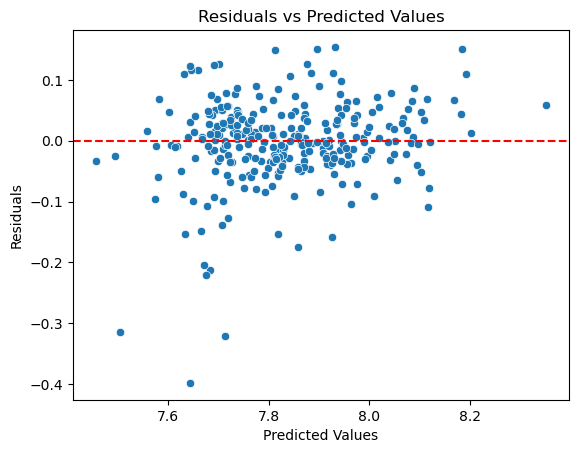

In [13]:
res = y_test - y_pred
sns.scatterplot(x=y_pred, y=res)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

### Check for multicollinearity

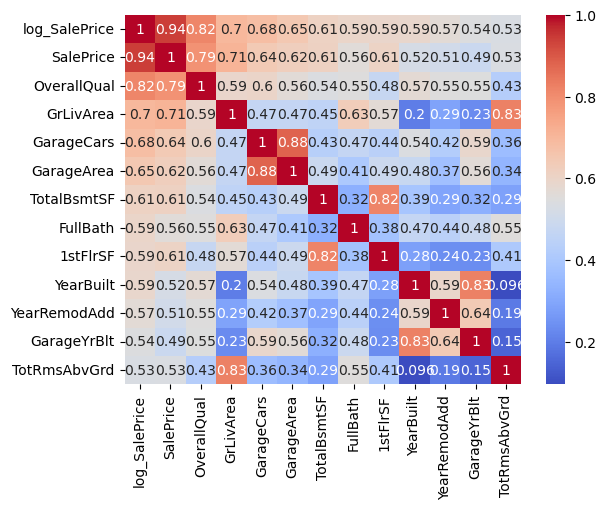

In [14]:

# Check for multicollinearity
sns.heatmap(train[importances_feat].corr(), annot=True, cmap='coolwarm')
plt.show()